# 02 Testing Purifying Selection hypothesis

Here we are introducing new AF metrices that we added 


## Variant Count Metrics

### **n_variants**
- **Type:** Integer
- **Description:** Total number of unique variants in this gene
- **Calculation:** Count of unique variant_id after deduplication by highest absolute effect

### **n_variants_common**
- **Type:** Integer
- **Description:** Number of common variants (AF ≥ 0.05)
- **Calculation:** Count where AF ≥ 0.05

### **n_variants_rare**
- **Type:** Integer
- **Description:** Number of rare variants (AF < 0.05)
- **Calculation:** Count where AF < 0.05

### **n_variants_common_perm**
- **Type:** Integer
- **Description:** Number of variants with permuted AF ≥ 0.05
- **Calculation:** Count where perm_AF ≥ 0.05
- **Note:** Only present when permuted AFs are available

### **n_variants_rare_perm**
- **Type:** Integer
- **Description:** Number of variants with permuted AF < 0.05
- **Calculation:** Count where perm_AF < 0.05
- **Note:** Only present when permuted AFs are available

### **variants_per_kb**
- **Type:** Float
- **Description:** Variant density normalized by genomic length
- **Calculation:** n_variants / (genomic_length / 1000)

## Genetic Variance (Vg) Metrics

### **vg_predicted**
- **Type:** Float
- **Description:** Total predicted genetic variance for this gene
- **Formula:** Σ[2 × AF × (1 - AF) × β²] across all variants
- **Note:** Primary Vg metric using observed allele frequencies

### **vg_predicted_perm**
- **Type:** Float
- **Description:** Total predicted genetic variance using permuted allele frequencies
- **Formula:** Σ[2 × perm_AF × (1 - perm_AF) × β²]
- **Note:** Used as null expectation for selection analyses

### **vg_common**
- **Type:** Float
- **Description:** Genetic variance contribution from common variants (AF ≥ 0.05)
- **Calculation:** Sum of vg_contribution where AF ≥ 0.05

### **vg_rare**
- **Type:** Float
- **Description:** Genetic variance contribution from rare variants (AF < 0.05)
- **Calculation:** Sum of vg_contribution where AF < 0.05

### **vg_common_perm**
- **Type:** Float
- **Description:** Genetic variance from common variants using permuted AFs
- **Note:** Only present when permuted AFs are available

### **vg_rare_perm**
- **Type:** Float
- **Description:** Genetic variance from rare variants using permuted AFs
- **Note:** Only present when permuted AFs are available


In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [7]:
from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = '02_af_filter'

print('\nDatasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')


Datasets:
  clingen: ClinGen_HI_Gnomad_genes_21022026.parquet
  clingen_null: ClinGen_HI_Synth_genes_21022026.parquet
  background: Background_Gnomad_genes_21022026.parquet
  background_null: Background_Synth_genes_21022026.parquet


In [8]:
real_gene_dfs = []
synth_gene_dfs = []

for key, path in GENE_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_gene_dfs.append(lf)
    else:
        real_gene_dfs.append(lf)

df_real = pl.concat(real_gene_dfs).collect()
df_synth = pl.concat(synth_gene_dfs).collect()

df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')
df_hi_synth = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi.height} genes')
print(f'Background: {df_bg.height} genes')
print(f'ClinGen HI (Synth): {df_hi_synth.height} genes')
print(f'Background (Synth): {df_bg_synth.height} genes')

ClinGen HI: 316 genes
Background: 349 genes
ClinGen HI (Synth): 316 genes
Background (Synth): 349 genes


In [9]:
print('df_real columns:', sorted(df_real.columns))
print('df_synth columns:', sorted(df_synth.columns))

candidate_cols = [
    c for c in df_real.columns
    if any(k in c.lower() for k in ['af', 'vg', 'promoter', 'upstream', 'downstream', 'tss', 'region'])
]
print('\nCandidate columns in df_real:')
for c in sorted(candidate_cols):
    print(' ', c)

for col in ['vg_predicted', 'vg_common', 'vg_rare', 'n_variants_common', 'n_variants_rare']:
    if col in df_real.columns:
        print(f"\n{col} summary:")
        print(
            df_real.select(
                pl.col(col).drop_nans().drop_nulls().alias(col)
            ).to_pandas()[col].describe(percentiles=[0.25, 0.5, 0.75])
        )

df_real columns: ['Episcore', 'N85', 'N90', 'RVIS_score', 'af_gradient', 'chrom', 'coding_length', 'cv_effect_N90', 'depletion_common', 'depletion_distal_upstream', 'depletion_down_distal', 'depletion_down_proximal', 'depletion_high_impact', 'depletion_promoter_core', 'depletion_proximal_upstream', 'depletion_rare', 'enrich_vg_distal_upstream', 'enrich_vg_down_distal', 'enrich_vg_down_proximal', 'enrich_vg_promoter_core', 'enrich_vg_proximal_upstream', 'entropy_distal_upstream', 'entropy_down_distal', 'entropy_down_proximal', 'entropy_effect', 'entropy_promoter_core', 'entropy_proximal_upstream', 'exonic_length', 'frac_high_impact_05', 'frac_high_impact_10', 'gene_id', 'gene_symbol', 'gene_type', 'genomic_length', 'intronic_length', 'is_mane', 'loeuf_score', 'mane_transcript_id', 'max_abs_effect', 'max_dist_to_tss', 'max_variant_id', 'max_variant_score', 'mean_abs_distal_upstream', 'mean_abs_down_distal', 'mean_abs_down_proximal', 'mean_abs_effect', 'mean_abs_promoter_core', 'mean_abs_

In [10]:
NOTEBOOK_NAME = '02_af_filter'

SOURCE_ORDER = ['background', 'background_null', 'clingen', 'clingen_null']
PLOT_LABELS = {
    'clingen': 'ClinGen_HI_Gnomad',
    'clingen_null': 'ClinGen_HI_Synth',
    'background': 'Background_Gnomad',
    'background_null': 'Background_Synth',
}

palette = {
    'background': SOURCE_PALETTE['background'],
    'background_null': SOURCE_PALETTE['background_null'],
    'clingen': SOURCE_PALETTE['clingen'],
    'clingen_null': SOURCE_PALETTE['clingen_null'],
}

required_cols = [
    'source', 'gene_symbol',
    'vg_predicted', 'vg_predicted_perm',
    'vg_common', 'vg_common_perm',
    'vg_rare', 'vg_rare_perm',
    'n_variants_common', 'n_variants_rare', 'variants_per_kb',
    'loeuf_score',
]

all_genes = pl.concat([df_real, df_synth], how='diagonal_relaxed')
missing_cols = [c for c in required_cols if c not in all_genes.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

is_synth = pl.col('source').str.contains('null')

plot_df = (
    all_genes
    .select(required_cols)
    .with_columns([
        pl.when(is_synth).then(pl.col('vg_predicted_perm')).otherwise(pl.col('vg_predicted')).alias('vg_total_for_plot'),
        pl.when(is_synth).then(pl.col('vg_common_perm')).otherwise(pl.col('vg_common')).alias('vg_common_for_plot'),
        pl.when(is_synth).then(pl.col('vg_rare_perm')).otherwise(pl.col('vg_rare')).alias('vg_rare_for_plot'),
    ])
    .with_columns([
        pl.when(pl.col('vg_total_for_plot') > 0)
        .then(pl.col('vg_rare_for_plot') / pl.col('vg_total_for_plot'))
        .otherwise(None)
        .alias('vg_rare_fraction'),
        pl.when(pl.col('vg_total_for_plot') > 0)
        .then(pl.col('vg_common_for_plot') / pl.col('vg_total_for_plot'))
        .otherwise(None)
        .alias('vg_common_fraction'),
    ])
    .filter(pl.col('source').is_in(SOURCE_ORDER))
    .drop_nulls(subset=['source', 'vg_total_for_plot'])
    .to_pandas()
)

plot_df['source_label'] = plot_df['source'].map(PLOT_LABELS)
source_label_order = [PLOT_LABELS[s] for s in SOURCE_ORDER]
palette_by_label = {PLOT_LABELS[s]: palette[s] for s in SOURCE_ORDER}

print('Phase 2 config and shared data prepared.')

Phase 2 config and shared data prepared.


# Phase 2 — The Filter (AF Analysis)

Is this variance driven by common variation or rare, potentially deleterious mutations?

[save_plot] Saved: figuree_AF_Filter_Selection_Shift_GnomAD_vs_SynthPerm_ByCohort_20022026_1222.pdf
[save_plot] Saved: figuree_AF_Filter_Selection_Shift_GnomAD_vs_SynthPerm_ByCohort_20022026_1222.svg


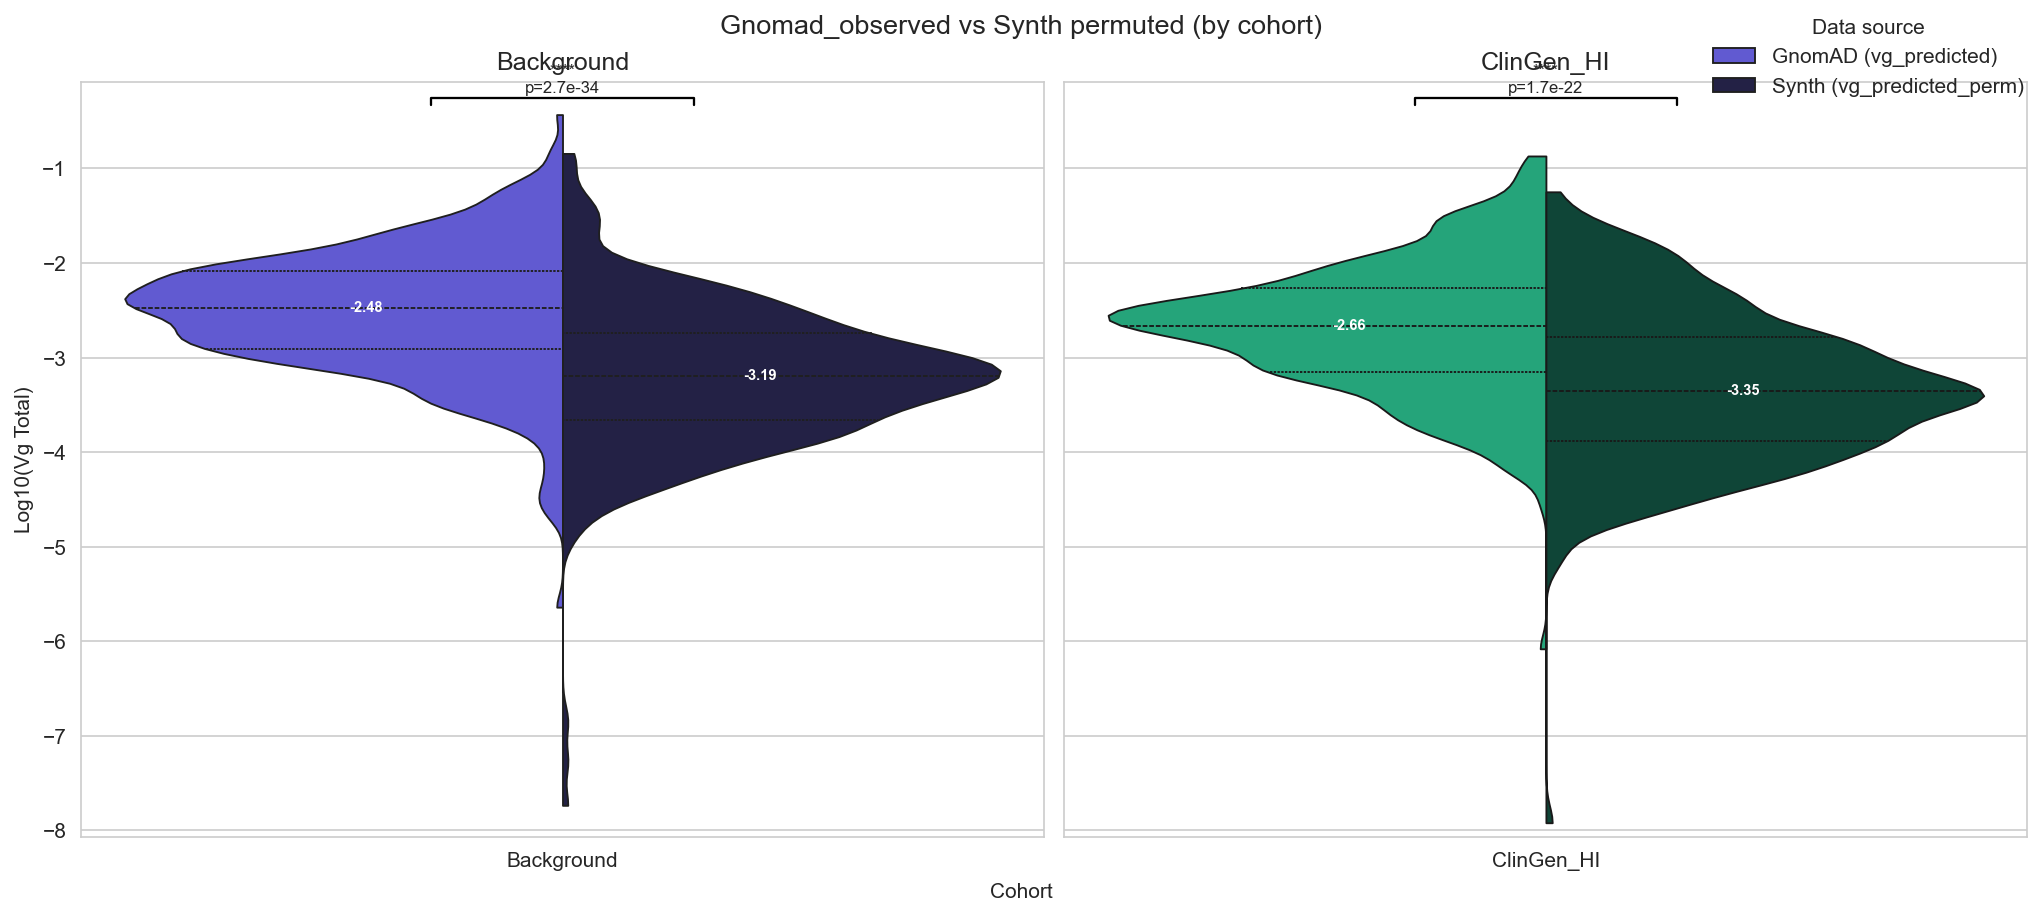

In [11]:
selection_df = all_genes.select(['source', 'vg_predicted', 'vg_predicted_perm']).to_pandas()
selection_df = selection_df[selection_df['source'].isin(SOURCE_ORDER)].copy()

selection_df['cohort'] = np.where(
    selection_df['source'].str.contains('background'),
    'Background',
    'ClinGen_HI',
)
selection_df['dataset_type'] = np.where(
    selection_df['source'].str.contains('null'),
    'Synth (vg_predicted_perm)',
    'GnomAD (vg_predicted)',
)
selection_df['vg_total_for_plot'] = np.where(
    selection_df['source'].str.contains('null'),
    selection_df['vg_predicted_perm'],
    selection_df['vg_predicted'],
)
selection_df = selection_df[selection_df['vg_total_for_plot'] > 0].copy()
selection_df['log10_vg_total'] = np.log10(selection_df['vg_total_for_plot'])
selection_df['panel'] = selection_df['cohort']

def _p_to_stars(p_value):
    if p_value < 1e-4:
        return '****'
    if p_value < 1e-3:
        return '***'
    if p_value < 1e-2:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'

with autosave('AF_Filter_Selection_Shift_GnomAD_vs_SynthPerm_ByCohort'):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.0), sharey=True, constrained_layout=True)

    panel_order = ['Background', 'ClinGen_HI']
    hue_order = ['GnomAD (vg_predicted)', 'Synth (vg_predicted_perm)']

    global_y_min = selection_df['log10_vg_total'].min()
    global_y_max = selection_df['log10_vg_total'].max()

    for ax, panel in zip(axes, panel_order):
        sub = selection_df[selection_df['panel'] == panel].copy()

        panel_palette = {
            'GnomAD (vg_predicted)': SOURCE_PALETTE['background'] if panel == 'Background' else SOURCE_PALETTE['clingen'],
            'Synth (vg_predicted_perm)': SOURCE_PALETTE['background_null'] if panel == 'Background' else SOURCE_PALETTE['clingen_null'],
        }

        sns.violinplot(
            data=sub,
            x='panel',
            y='log10_vg_total',
            hue='dataset_type',
            order=[panel],
            hue_order=hue_order,
            split=True,
            dodge=True,
            inner='quart',
            cut=0,
            bw_adjust=0.65,
            linewidth=0.9,
            palette=panel_palette,
            ax=ax,
        )

        gnomad_vals = sub[sub['dataset_type'] == 'GnomAD (vg_predicted)']['log10_vg_total'].dropna()
        synth_vals = sub[sub['dataset_type'] == 'Synth (vg_predicted_perm)']['log10_vg_total'].dropna()

        # Add white median annotations
        if len(gnomad_vals) > 0:
            gnomad_median = gnomad_vals.median()
            ax.text(-0.18, gnomad_median, f'{gnomad_median:.2f}', 
                   ha='center', va='center', fontsize=7, color='white', weight='bold')
        
        if len(synth_vals) > 0:
            synth_median = synth_vals.median()
            ax.text(0.18, synth_median, f'{synth_median:.2f}', 
                   ha='center', va='center', fontsize=7, color='white', weight='bold')

        y_top = global_y_max + 0.18
        if len(gnomad_vals) >= 3 and len(synth_vals) >= 3:
            _, p_val = stats.mannwhitneyu(gnomad_vals, synth_vals, alternative='two-sided')
            x1, x2 = -0.12, 0.12
            bracket_h = 0.08
            ax.plot([x1, x1, x2, x2], [y_top - bracket_h, y_top, y_top, y_top - bracket_h], lw=1.1, c='black')
            ax.text(0, y_top + 0.02, f"{_p_to_stars(p_val)}\np={p_val:.1e}", ha='center', va='bottom', fontsize=8)

        ax.set_ylim(global_y_min - 0.15, global_y_max + 0.35)
        ax.set_title(panel, fontsize=12)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=0)

        legend_ = ax.get_legend()
        if legend_ is not None:
            legend_.remove()

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles[:2], labels[:2], title='Data source', frameon=False, loc='upper right')

    axes[0].set_ylabel('Log10(Vg Total)', fontsize=10)
    axes[1].set_ylabel('')
    fig.supxlabel('Cohort', fontsize=10)
    fig.suptitle('Gnomad_observed vs Synth permuted (by cohort)', fontsize=13)

ClinGen haploinsufficient genes display a significant depletion in genetic variancecompared to null expectations (p<10−21), evidencing strong purifying selection that is notably absent in the background gene set.

# Rare/Common ratio vs constraint (LOEUF deciles)

[save_plot] Saved: figuree_AF_Filter_CommonFraction_vs_LOEUF_Deciles_withTrend_20022026_1222.pdf
[save_plot] Saved: figuree_AF_Filter_CommonFraction_vs_LOEUF_Deciles_withTrend_20022026_1222.svg


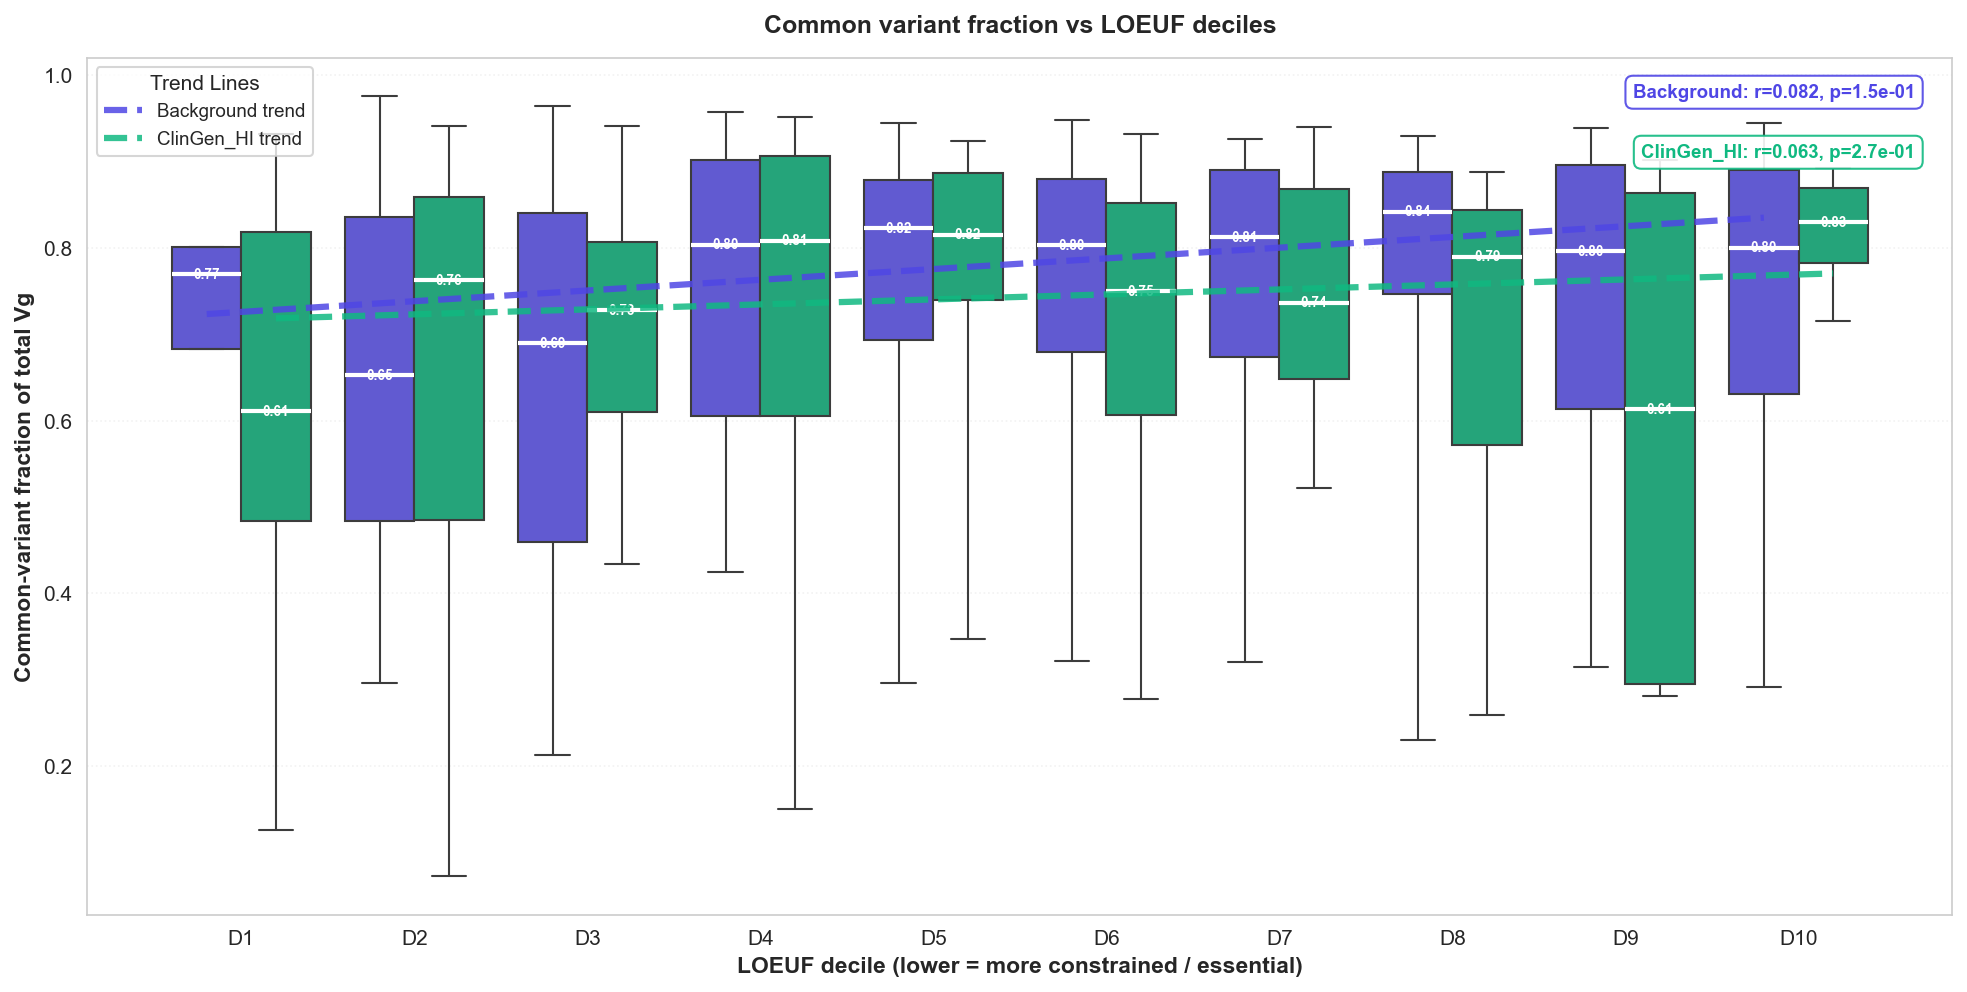

In [12]:
plot6_df = plot_df.copy()
plot6_df = plot6_df[
    (~plot6_df['source'].str.contains('null'))
    & plot6_df['loeuf_score'].notna()
    & plot6_df['vg_common_fraction'].notna()
].copy()

plot6_df['loeuf_decile'] = pd.qcut(
    plot6_df['loeuf_score'],
    q=10,
    labels=[f'D{i}' for i in range(1, 11)],
    duplicates='drop',
)

with autosave('AF_Filter_CommonFraction_vs_LOEUF_Deciles_withTrend'):
    fig, ax = plt.subplots(figsize=(13, 6.5), constrained_layout=True)
    
    hue_labels = [PLOT_LABELS['background'], PLOT_LABELS['clingen']]
    
    sns.boxplot(
        data=plot6_df,
        x='loeuf_decile',
        y='vg_common_fraction',
        hue='source_label',
        hue_order=hue_labels,
        palette={
            PLOT_LABELS['background']: palette['background'],
            PLOT_LABELS['clingen']: palette['clingen'],
        },
        showfliers=False,
        medianprops={'color': 'white', 'linewidth': 2.0},
        whis=[5, 95],
        ax=ax,
    )
    
    deciles = plot6_df['loeuf_decile'].cat.categories
    n_hues = len(hue_labels)
    box_width = 0.8 / n_hues
    
    for j, hue_label in enumerate(hue_labels):
        subset_full = plot6_df[plot6_df['source_label'] == hue_label]
        color = palette['background'] if 'Background' in hue_label else palette['clingen']
        
        decile_x_positions = []
        decile_medians = []
        
        for i, decile in enumerate(deciles):
            subset = plot6_df[(plot6_df['loeuf_decile'] == decile) & (plot6_df['source_label'] == hue_label)]
            if len(subset) > 0:
                median_val = subset['vg_common_fraction'].median()
                x_pos = i + (j - 0.5) * box_width
                decile_x_positions.append(x_pos)
                decile_medians.append(median_val)
                
                ax.text(x_pos, median_val, f'{median_val:.2f}', 
                       ha='center', va='center', fontsize=6.5, color='white', weight='bold')
        
        if len(decile_x_positions) > 2:
            z = np.polyfit(decile_x_positions, decile_medians, 1)
            p = np.poly1d(z)
            x_trend = np.linspace(min(decile_x_positions), max(decile_x_positions), 100)
            ax.plot(x_trend, p(x_trend), color=color, linewidth=3.0, linestyle='--', 
                   alpha=0.85, zorder=10, label=f'{hue_label.replace("_Gnomad", "")} trend')
        
        if len(subset_full) > 5:
            corr = subset_full[['loeuf_score', 'vg_common_fraction']].corr().iloc[0, 1]
            pval = stats.pearsonr(subset_full['loeuf_score'], subset_full['vg_common_fraction'])[1]
            
            y_pos = 0.97 if 'Background' in hue_label else 0.90
            label_text = f"{hue_label.replace('_Gnomad', '')}: r={corr:.3f}, p={pval:.1e}"
            ax.text(0.98, y_pos, label_text, transform=ax.transAxes,
                   ha='right', va='top', fontsize=9, color=color, weight='bold',
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=color, alpha=0.9))
    
    ax.set_xlabel('LOEUF decile (lower = more constrained / essential)', fontsize=11, weight='bold')
    ax.set_ylabel('Common-variant fraction of total Vg', fontsize=11, weight='bold')
    ax.set_title('Common variant fraction vs LOEUF deciles', 
                fontsize=12, weight='bold', pad=12)
    ax.grid(True, alpha=0.25, linestyle=':', axis='y')
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[2:], labels[2:], title='Trend Lines', frameon=True, loc='upper left', fontsize=9)

 Essential genes (low LOEUF deciles D1-D3) have lower common-variant fractions (0.60-0.70), while less constrained genes (high LOEUF deciles D8-D10) have higher fractions (0.80-0.90).  "High-impact variants were depleted in common variation" - essential genes are intolerant to common regulatory noise.